In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
from tqdm import tqdm

sys.path.append("../")

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"

BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"


sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)

X_pixel = np.concatenate([sig_pixel_spacetime, bg_pixel_spacetime], axis=0)
X_mppc = np.concatenate([sig_mppc_spacetime, bg_mppc_spacetime], axis=0)
y = np.concatenate(
    [np.ones(sig_pixel_spacetime.shape[0]), np.zeros(bg_pixel_spacetime.shape[0])],
    axis=0,
)


# --------------------------------
# Functions to convert MPPC and pixel IDs to positions in space
# --------------------------------
from sklearn.model_selection import train_test_split

X_pixel_train, X_pixel_val, X_mppc_train, X_mppc_val, y_train, y_val = train_test_split(
    X_pixel, X_mppc, y, test_size=0.2, random_state=42, stratify=y
)
del X_pixel, X_mppc, y

In [2]:
((X_mppc_train[0,:, -1])//8)*8

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  8.,  8.,  8.,  8.,
        8., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16.,
       16., 16., 16., 16., 16., 16., 16., 16., 16., 24., 24., 24., 32.,
       32., 48., 48., 48., 48., 48., 48., 48., 48., 48., 48., 48., 48.,
       48., 48., 48., 48., 48., 48., 56., 56., 56., 56., 56., 56., 56.,
       56., 56., 56., 56., 56., 56., 56., 56., 56., 56., 56., 56., 56.,
       56., 56., 56., 56., 56., 56., 56., 56., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8.,
       -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8., -8

In [3]:
def get_sliced_data(X_pixel, X_mppc,y):
    """Splits the data into time slices"""
    pixel_slices = []
    mppc_slices = []
    labels = []
    for i in range(X_pixel.shape[0]):
        pixel_event = X_pixel[i]
        mppc_event = X_mppc[i]
        label = y[i]
        # Get unique time slices
        time_slices = np.unique(pixel_event[:, -1])
        for t in time_slices:
            if ~np.any(((mppc_event[:, -1])//8)*8 == t): 
                continue
            pixel_mask = pixel_event[:, -1] == t
            mppc_mask = ((mppc_event[:, -1])//8)*8 == t
            pixel_slices.append(pixel_event[pixel_mask, :3])
            mppc_slices.append(np.concat([mppc_event[mppc_mask, :3],mppc_event[mppc_mask, -1].reshape(-1,1) - t], axis=1))
            labels.append(label)
    return pixel_slices, mppc_slices, np.array(labels)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import List, Tuple, Dict, Any
from sklearn.metrics import accuracy_score, roc_auc_score

class SlicedDataset(Dataset):
    """Efficient dataset for handling sliced pixel and MPPC data"""
    
    def __init__(self, pixel_slices: List[np.ndarray], mppc_slices: List[np.ndarray], labels: np.ndarray):
        self.pixel_slices = [torch.FloatTensor(p) for p in pixel_slices]
        self.mppc_slices = [torch.FloatTensor(m) for m in mppc_slices]
        self.labels = torch.LongTensor(labels)
        
    def __len__(self):
        return len(self.pixel_slices)
    
    def __getitem__(self, idx):
        return {
            'pixel': self.pixel_slices[idx],
            'mppc': self.mppc_slices[idx],
            'label': self.labels[idx]
        }

def efficient_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
    """Memory-efficient collate function using padding instead of concatenation"""
    batch_size = len(batch)
    
    # Find max lengths for padding
    max_pixel_len = max(item['pixel'].size(0) for item in batch)
    max_mppc_len = max(item['mppc'].size(0) for item in batch)
    
    # Pre-allocate tensors
    pixel_data = torch.zeros(batch_size, max_pixel_len, 3)
    mppc_data = torch.zeros(batch_size, max_mppc_len, 4)
    pixel_lengths = torch.zeros(batch_size, dtype=torch.long)
    mppc_lengths = torch.zeros(batch_size, dtype=torch.long)
    labels = torch.zeros(batch_size, dtype=torch.long)
    
    # Fill tensors efficiently
    for i, item in enumerate(batch):
        pixel_len = item['pixel'].size(0)
        mppc_len = item['mppc'].size(0)
        
        pixel_data[i, :pixel_len] = item['pixel']
        mppc_data[i, :mppc_len] = item['mppc']
        pixel_lengths[i] = pixel_len
        mppc_lengths[i] = mppc_len
        labels[i] = item['label']
    
    return {
        'pixel_data': pixel_data,
        'mppc_data': mppc_data,
        'pixel_lengths': pixel_lengths,
        'mppc_lengths': mppc_lengths,
        'labels': labels
    }

class EfficientAttention(nn.Module):
    """Memory-efficient attention with length-based masking"""
    
    def __init__(self, d_model: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.w_qkv = nn.Linear(d_model, 3 * d_model, bias=False)  # Combined QKV projection
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, _ = x.size()
        
        # Single matrix multiplication for Q, K, V
        qkv = self.w_qkv(x)  # [batch_size, seq_len, 3 * d_model]
        qkv = qkv.view(batch_size, seq_len, 3, self.num_heads, self.d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # [3, batch_size, num_heads, seq_len, d_k]
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Efficient attention computation
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)
        
        # Create efficient length-based mask
        mask = torch.arange(seq_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
        mask = mask.unsqueeze(1).unsqueeze(2)  # [batch_size, 1, 1, seq_len]
        scores.masked_fill_(mask, float('-inf'))
        
        attention = F.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        
        out = torch.matmul(attention, v)  # [batch_size, num_heads, seq_len, d_k]
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        return self.w_o(out)

class EfficientBinaryClassifier(nn.Module):
    """Efficient attention-based binary classifier"""
    
    def __init__(self, pixel_input_dim: int = 3, mppc_input_dim: int = 4, 
                 d_model: int = 64, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        
        self.d_model = d_model
        
        # Lightweight input projections
        self.pixel_proj = nn.Linear(pixel_input_dim, d_model)
        self.mppc_proj = nn.Linear(mppc_input_dim, d_model)
        
        # Single attention layer (often sufficient)
        self.attention = EfficientAttention(d_model, num_heads, dropout)
        self.norm = nn.LayerNorm(d_model)
        
        # Lightweight FFN
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        
        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, pixel_data: torch.Tensor, mppc_data: torch.Tensor,
                pixel_lengths: torch.Tensor, mppc_lengths: torch.Tensor) -> torch.Tensor:
        batch_size = pixel_data.size(0)
        
        # Project inputs
        pixel_emb = self.pixel_proj(pixel_data)  # [batch_size, max_pixel_len, d_model]
        mppc_emb = self.mppc_proj(mppc_data)     # [batch_size, max_mppc_len, d_model]
        
        # Process each modality separately (much more efficient)
        pixel_out = self.attention(pixel_emb, pixel_lengths)
        mppc_out = self.attention(mppc_emb, mppc_lengths)
        
        # Apply FFN
        pixel_out = self.norm(pixel_out + self.ffn(pixel_out))
        mppc_out = self.norm(mppc_out + self.ffn(mppc_out))
        
        # Efficient pooling using lengths
        pixel_pooled = self.length_aware_pool(pixel_out, pixel_lengths)
        mppc_pooled = self.length_aware_pool(mppc_out, mppc_lengths)
        
        # Combine representations
        combined = pixel_pooled + mppc_pooled  # Simple addition instead of concatenation
        
        return self.classifier(combined).squeeze(-1)
    
    def length_aware_pool(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """Efficient length-aware mean pooling"""
        batch_size, max_len, d_model = x.size()
        
        # Create mask
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).float()  # [batch_size, max_len, 1]
        
        # Masked mean
        masked_sum = (x * mask).sum(dim=1)  # [batch_size, d_model]
        lengths_clamped = lengths.clamp(min=1).float().unsqueeze(-1)  # Avoid division by 0
        
        return masked_sum / lengths_clamped

def train_model_efficient(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                         num_epochs: int = 50, lr: float = 1e-3, device: str = 'cuda'):
    """Efficient training with gradient accumulation and mixed precision"""
    
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(weight=torch.tensor(10, device=device))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    )
    
    # Mixed precision for faster training
    scaler = torch.cuda.amp.GradScaler() if device == 'cuda' else None
    
    best_val_acc = 0
    best_val_auc = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # Move to device efficiently
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            
            optimizer.zero_grad()
            
            # Mixed precision forward pass
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(
                        batch['pixel_data'], batch['mppc_data'],
                        batch['pixel_lengths'], batch['mppc_lengths']
                    )
                    loss = criterion(logits, batch['labels'].float())
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(
                    batch['pixel_data'], batch['mppc_data'],
                    batch['pixel_lengths'], batch['mppc_lengths']
                )
                loss = criterion(logits, batch['labels'].float())
                loss.backward()
                optimizer.step()
            
            scheduler.step()
            train_loss += loss.item()
        
        # Validation
        if epoch % 5 == 0:  # Validate less frequently
            model.eval()
            correct = 0
            total = 0
            
            predictions_list = []
            labels_list = []
            with torch.no_grad():
                for batch in val_loader:
                    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
                    
                    logits = model(
                        batch['pixel_data'], batch['mppc_data'],
                        batch['pixel_lengths'], batch['mppc_lengths']
                    )
                    
                    predictions = (torch.sigmoid(logits) > 0.5).long()
                    correct += (predictions == batch['labels']).sum().item()
                    predictions_list.extend(torch.sigmoid(logits).cpu().numpy())
                    labels_list.extend(batch['labels'].cpu().numpy())
                    total += batch['labels'].size(0)
            
            # Calculate AUC
            val_auc = roc_auc_score(labels_list, predictions_list)
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                torch.save(model.state_dict(), 'best_model_auc.pth')
            val_acc = correct / total
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), 'best_model.pth')
            
            print(f'Epoch {epoch}: Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.4f}, Val AUC: {val_auc:.4f}')
    
    return best_val_acc

def run_attention_model(X_pixel: np.ndarray, X_mppc: np.ndarray, y: np.ndarray,
                       test_size: float = 0.2, batch_size: int = 64, num_epochs: int = 30,
                       device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
    """Optimized plug-and-play function"""
    
    # Get sliced data
    pixel_slices, mppc_slices, labels = get_sliced_data(X_pixel, X_mppc, y)
    
    # Train-test split
    n_samples = len(pixel_slices)
    indices = np.random.permutation(n_samples)
    split_idx = int(n_samples * (1 - test_size))
    
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    # Create datasets
    train_dataset = SlicedDataset(
        [pixel_slices[i] for i in train_indices],
        [mppc_slices[i] for i in train_indices],
        labels[train_indices]
    )
    
    val_dataset = SlicedDataset(
        [pixel_slices[i] for i in val_indices],
        [mppc_slices[i] for i in val_indices],
        labels[val_indices]
    )
    
    # Optimized data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, 
        collate_fn=efficient_collate_fn
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size * 2, shuffle=False,
        collate_fn=efficient_collate_fn
    )
    
    # Smaller, more efficient model
    model = EfficientBinaryClassifier(d_model=32, num_heads=4)
    
    # Train model
    best_acc = train_model_efficient(model, train_loader, val_loader, num_epochs, device=device)
    


In [10]:
num_epochs=20
batch_size=512
device='cuda' if torch.cuda.is_available() else 'cpu'
test_size = 0.2
# Get sliced data
pixel_slices, mppc_slices, labels = get_sliced_data(X_pixel_train, X_mppc_train, y_train)

# Train-test split
n_samples = len(pixel_slices)
indices = np.random.permutation(n_samples)
split_idx = int(n_samples * (1 - test_size))

train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

# Create datasets
train_dataset = SlicedDataset(
    [pixel_slices[i] for i in train_indices],
    [mppc_slices[i] for i in train_indices],
    labels[train_indices]
)

val_dataset = SlicedDataset(
    [pixel_slices[i] for i in val_indices],
    [mppc_slices[i] for i in val_indices],
    labels[val_indices]
)

# Optimized data loaders
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, 
    collate_fn=efficient_collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size * 2, shuffle=False,
    collate_fn=efficient_collate_fn
)

# Smaller, more efficient model
model = EfficientBinaryClassifier(d_model=32, num_heads=4)

# Train model
best_acc = train_model_efficient(model, train_loader, val_loader, num_epochs, device=device)


Epoch 1/20: 100%|██████████| 1292/1292 [11:02<00:00,  1.95it/s]


Epoch 0: Train Loss: 4.1530, Val Acc: 0.8946, Val AUC: 0.6852


Epoch 6/20:   6%|▌         | 73/1292 [00:40<11:14,  1.81it/s]


KeyboardInterrupt: 

In [11]:
transformer_val_dataset = SlicedDataset(
    *get_sliced_data(X_pixel_val, X_mppc_val, y_val)
)
transformer_val_loader = DataLoader(
    val_dataset, batch_size=512, shuffle=False,
    collate_fn=efficient_collate_fn
)

transformer_test_predictions = []
tranformer_test_labels = []
model.eval()
with torch.no_grad():
    for batch in tqdm(transformer_val_loader, desc="Testing"):
        batch = {k: v.to("cpu", non_blocking=True) for k, v in batch.items()}
        
        logits = model(
            batch['pixel_data'], batch['mppc_data'],
            batch['pixel_lengths'], batch['mppc_lengths']
        )
        
        transformer_test_predictions.extend(torch.sigmoid(logits).cpu().numpy())
        tranformer_test_labels.extend(batch['labels'].cpu().numpy())

transformer_test_predictions = np.array(transformer_test_predictions)
tranformer_test_labels = np.array(tranformer_test_labels)

Testing: 100%|██████████| 323/323 [00:43<00:00,  7.38it/s]


In [12]:
gnn_test_predictions = np.load(f"{MODEL_DIR}/graph_classifier_val_preds.npy")
gnn_test_labels = np.load(f"{MODEL_DIR}/graph_classifier_val_labels.npy")

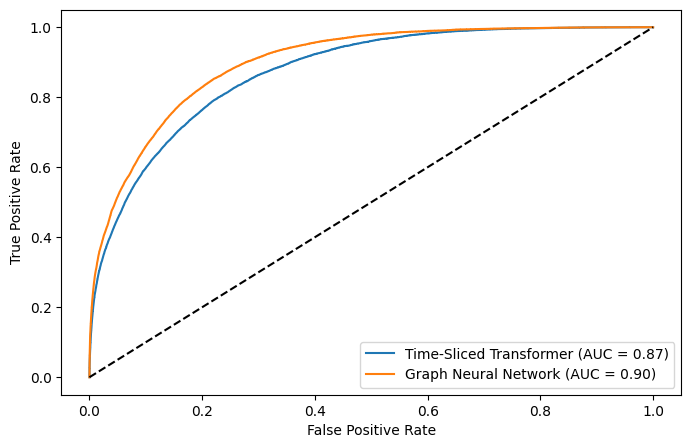

In [14]:
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(8, 5))
transformer_fpr, transformer_tpr, _ = roc_curve(tranformer_test_labels, transformer_test_predictions)
transformer_roc_auc = auc(transformer_fpr, transformer_tpr)
gnn_fpr, gnn_tpr, _ = roc_curve(gnn_test_labels, gnn_test_predictions)
gnn_roc_auc = auc(gnn_fpr, gnn_tpr)
ax.plot(transformer_fpr, transformer_tpr, label=f'Time-Sliced Transformer (AUC = {transformer_roc_auc:.2f})')
ax.plot(gnn_fpr, gnn_tpr, label=f'Graph Neural Network (AUC = {gnn_roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
fig.savefig(f"{PLOTS_DIR}/transformer_vs_gnn_roc_curve.png")